### SINDy-SHRED applied to SST dataset

This iPython notebook gives an introductory walkthrough to using SHRED models.  The dataset we consider is weekly mean sea-surface temperature as given by the NOAA Optimum Interpolation SST V2 dataset (https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html).

SHRED (SHallow REcurrent Decoder) models are a network architecture that merges a recurrent layer (LSTM) with a shallow decoder network (SDN) to reconstruct high-dimensional spatio-temporal fields from a trajectory of sensor measurements of the field. More formally, the SHRED architecture can be written as
$$ \mathcal {H} \left( \{ y_i \} _{i=t-k}^t \right) = \mathcal {F} \left( \mathcal {G} \left( \{ y_i \} _{i=t-k}^t \right) ; W_{RN}) ; W_{SD} \right)$$
where $\mathcal F$ is a feed forward network parameterized by weights $W_{SD}$, $\mathcal G$ is a LSTM network parameterized by weights $W_{RN}$, and $\{ y_i \} _{i=t-k}^t$ is a trajectory of sensor measurements of a high-dimensional spatio-temporal field $\{ x_i \} _{i=t-k}^t$.

SINDy-SHRED further extends the SHRED architecture by integrating **Sparse Identification of Nonlinear Dynamics (SINDy)** into the recurrent decoder framework. The key idea is to enforce a **parsimonious latent space representation**, where the dynamics of the latent variables are governed by a **sparse set of basis functions**.

More formally, SINDy-SHRED introduces an additional inductive bias:

$$\dot{z} = \Theta(z) \xi$$

where:

- $z = \mathcal{G} \left( \{ y_i \} _{i=t-k}^t \right)$ represents the **latent space variables** extracted by the LSTM encoder.
- $\Theta(z)$ is a **library of candidate nonlinear functions**.
- $\xi$ is a **sparse coefficient matrix** that determines the governing equations.

This combination enables **interpretable spatio-temporal modeling** by ensuring that the learned representations adhere to a **governing law**, making the method suitable for **data-driven discovery of dynamical systems** from high-dimensional, noisy observations.

In this notebook, we will walk through the application of **SINDy-SHRED** on the **weekly mean sea-surface temperature (SST) dataset**, demonstrating how the model can **learn a reduced-order latent representation** and **recover the governing equations** that describe the SST evolution.

We first randomly select 3 sensor locations and set the trajectory length (lags) to 52, corresponding to one year of measurements.

In [1]:
# Clone GitHub repository
!git clone https://github.com/fmenol/sindy-shred.git
!pip install pysindy==1.7.5 numpy==1.23.5 pandas==1.5.3 scipy==1.13.1 scikit-learn==1.5.2

Cloning into 'sindy-shred'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 128 (delta 40), reused 52 (delta 25), pack-reused 52 (from 1)
Receiving objects: 100% (128/128), 66.53 MiB | 15.96 MiB/s, done.
Resolving deltas: 100% (49/49), done.
Error downloading object: Data/SST_data.mat (5c49c48): Smudge error: Error downloading Data/SST_data.mat (5c49c487d48183b9ec6e6e0a8f3044c964c5731ed8a00b8074f37f395264b0e8): batch response: Git LFS is disabled for this repository.

Errors logged to /content/sindy-shred/.git/lfs/logs/20250430T173722.638366578.log
Use `git lfs logs last` to view the log.
error: external filter 'git-lfs filter-process' failed
fatal: Data/SST_data.mat: smudge filter lfs failed
You can inspect what was checked out with 'git status'
and retry with 'git restore --source=HEAD :/'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━

In [1]:
# Add the repressilator data
%cd sindy-shred
!pip install gdown -q
!gdown --id 1CBvH5qtWqBuiQIavL3l9ESZYKFmdyzry -O ./Data/

/content/sindy-shred
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1CBvH5qtWqBuiQIavL3l9ESZYKFmdyzry
To: /content/sindy-shred/Data/isolated_repressilator_1_6000_201_40.pkl
100% 67.5M/67.5M [00:01<00:00, 36.3MB/s]


## Loading the data

In [7]:
import numpy as np
import torch

# Make this into the folder
from processdata import load_data
from processdata import TimeSeriesDataset

import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import sindy
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
import pandas as pd
import tqdm

# Load the data
data = pd.read_pickle('/content/sindy-shred/Data/isolated_repressilator_1_6000_201_40.pkl')


# --- Data Processing ---
# The following functions are used to preprocess the data:
# 1. discrete_data_format: Converts the data into a format suitable for the model.
# 2. chunk_trajectory_data: Splits the data into chunks for training.

def discrete_data_format(df,chunk_size=1):
    X = []
    for i in tqdm.tqdm(df.index.unique()):
        x = torch.FloatTensor(df.loc[i].values)
        size = x.shape[0]
        if chunk_size > 1:
            size = int(size/chunk_size)
        x = torch.chunk(x,chunk_size)
        X.extend(x)
    X = torch.stack(X, 0)
    return X

data = discrete_data_format(data,chunk_size=1)

def chunk_trajectory_data(data, prediction_length, stride=None):
    """Split trajectory data into chunks for training."""
    if len(data.shape) == 2:  # Handle 2D data
        num_samples, state_dim = data.shape
        # Reshape to simulate trajectory data
        data = data.reshape(1, num_samples, state_dim)

    num_trajectories, timesteps, state_dim = data.shape
    chunk_size = prediction_length + 1

    if chunk_size > timesteps:
        raise ValueError("Chunk size cannot be greater than number of timesteps")

    stride = prediction_length if stride is None else stride
    chunks_per_traj = (timesteps - chunk_size) // stride + 1
    total_chunks = num_trajectories * chunks_per_traj

    chunks = np.zeros((total_chunks, chunk_size, state_dim))

    chunk_idx = 0
    for traj in range(num_trajectories):
        for start in range(0, timesteps - chunk_size + 1, stride):
            chunks[chunk_idx] = data[traj, start:start + chunk_size]
            chunk_idx += 1

    return chunks

data = chunk_trajectory_data(data, 200, stride=1)
print(data.shape)




print(data.shape)

100%|██████████| 6000/6000 [00:00<00:00, 8559.82it/s]


(6000, 201, 6)
(6000, 201, 6)


In [8]:
# Normalize the data where the data in shape (traj,time, dim)
# Ensure data is float32 before scaling
# Only using the first 600 trajectories
testing_traj = data[600:700]
data = data[:600].astype(np.float32)

sc = MinMaxScaler()
num_traj, num_time, num_dim = data.shape

data = data.reshape(num_traj * num_time, num_dim)
data = sc.fit_transform(data).astype(np.float32)  # Also ensure output is float32
data = data.reshape(num_traj, num_time, num_dim)

print(data.shape)
print(testing_traj.shape)

(600, 201, 6)
(100, 201, 6)


In [9]:
# testing trajectories
print(testing_traj.shape)
# transform the data using sc
test_num_traj, test_num_time, test_num_dim = testing_traj.shape
testing_traj = testing_traj.reshape(test_num_traj * test_num_time, test_num_dim)
testing_traj = sc.transform(testing_traj).astype(np.float32)
testing_traj = testing_traj.reshape(test_num_traj, test_num_time, test_num_dim)
print(testing_traj.shape)

(100, 201, 6)
(100, 201, 6)


In [10]:
import numpy as np

def create_lagged_dataset(trajectories, lag_size):
    """
    Create a dataset of input-output pairs from trajectory data.
    All trajectories are assumed to have the same length.

    Parameters:
    - trajectories: Array of shape (n_trajectories, trajectory_length, n_dimensions)
    - lag_size: Number of time steps to use as input

    Prints:
    - Information about the generated dataset, including shape and samples per trajectory
    """
    n_trajectories = trajectories.shape[0]
    trajectory_length = trajectories.shape[1]

    # Lists to store inputs and outputs
    X_list = []
    y_list = []

    # Track number of samples per trajectory
    samples_per_trajectory = trajectory_length - lag_size
    if samples_per_trajectory <= 0:
        raise ValueError("Lag size must be less than trajectory length")

    # Number of samples we can create from each trajectory
    n_samples_per_traj = trajectory_length - lag_size

    for i in range(n_trajectories):
        trajectory = trajectories[i]

        # Skip if trajectory is too short for the lag size
        if trajectory_length <= lag_size:
            continue

        for t in range(n_samples_per_traj):
            # Input: lag_size time steps, first 3 dimensions
            X_sample = trajectory[t:t+lag_size, :3]

            # Output: the next time step, all 6 dimensions
            y_sample = trajectory[t+lag_size, :6]

            X_list.append(X_sample)
            y_list.append(y_sample)

    # Convert lists to numpy arrays
    X = np.array(X_list)
    y = np.array(y_list)

    # Print information about the dataset
    print(f"Input shape: {X.shape}")  # Should be (n_samples, lag_size, 3)
    print(f"Output shape: {y.shape}")  # Should be (n_samples, 6)
    print(f"Samples per trajectory: {samples_per_trajectory}")
    print(f"Total number of data points: {len(X)}")
    print(len(X) / samples_per_trajectory)

    return X, y , samples_per_trajectory


data_in , data_out, samples_per_traj = create_lagged_dataset(data, 20)


Input shape: (108600, 20, 3)
Output shape: (108600, 6)
Samples per trajectory: 181
Total number of data points: 108600
600.0


In [11]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Assume data_in and data_out are NumPy arrays
data_in = data_in.astype(np.float32)
data_out = data_out.astype(np.float32)

train_length = int(0.8 * len(data_in) / samples_per_traj) * samples_per_traj
validation_length = int(0.1 * len(data_in) / samples_per_traj) * samples_per_traj

# Splits
train_data_in = torch.tensor(data_in[:train_length], dtype=torch.float32).to(device)
train_data_out = torch.tensor(data_out[:train_length], dtype=torch.float32).to(device)

valid_data_in = torch.tensor(data_in[train_length:train_length + validation_length], dtype=torch.float32).to(device)
valid_data_out = torch.tensor(data_out[train_length:train_length + validation_length], dtype=torch.float32).to(device)

test_data_in = torch.tensor(data_in[train_length + validation_length:], dtype=torch.float32).to(device)
test_data_out = torch.tensor(data_out[train_length + validation_length:], dtype=torch.float32).to(device)

# Print shapes
print("train_data_in shape:", train_data_in.shape)
print("train_data_out shape:", train_data_out.shape)
print("validation_data_in shape:", valid_data_in.shape)
print("validation_data_out shape:", valid_data_out.shape)
print("test_data_in shape:", test_data_in.shape)
print("test_data_out shape:", test_data_out.shape)


train_data_in shape: torch.Size([86880, 20, 3])
train_data_out shape: torch.Size([86880, 6])
validation_data_in shape: torch.Size([10860, 20, 3])
validation_data_out shape: torch.Size([10860, 6])
test_data_in shape: torch.Size([10860, 20, 3])
test_data_out shape: torch.Size([10860, 6])


## Data Preprocessing

Set random seed

In [12]:
import random
import numpy as np
import torch
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

In [13]:
train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
test_dataset = TimeSeriesDataset(test_data_in, test_data_out)

In [14]:
len(test_dataset)

10860

## SINDy SHRED Model

We set up SINDy library coefficients

In [15]:
latent_dim = 3
poly_order = 1
include_sine = False
library_dim = sindy.library_size(latent_dim, poly_order, include_sine, True)

We train the model using the training and validation datasets.

In [16]:
import sindy_shred

# Initialize the model
shred = sindy_shred.SINDy_SHRED(3, 6, hidden_size=latent_dim, hidden_layers=2, l1=350, l2=400, dropout=0.1,
                                 library_dim=library_dim, poly_order=poly_order,
                                include_sine=include_sine, dt=0.2*0.1, layer_norm=False).to(device)

validation_errors = sindy_shred.fit(shred, train_dataset, valid_dataset, batch_size=150, num_epochs=100,
                                    lr=1e-3, verbose=True, threshold=0.25, patience=5, sindy_regularization=10.0,
                                    optimizer="AdamW", thres_epoch=20)

1 : tensor(0.0012, device='cuda:0', grad_fn=<AddBackward0>)
2 : tensor(0.0009, device='cuda:0', grad_fn=<AddBackward0>)
3 : tensor(0.0007, device='cuda:0', grad_fn=<AddBackward0>)
4 : tensor(0.0005, device='cuda:0', grad_fn=<AddBackward0>)
5 : tensor(0.0005, device='cuda:0', grad_fn=<AddBackward0>)
6 : tensor(0.0004, device='cuda:0', grad_fn=<AddBackward0>)
7 : tensor(0.0003, device='cuda:0', grad_fn=<AddBackward0>)
8 : tensor(0.0003, device='cuda:0', grad_fn=<AddBackward0>)
9 : tensor(0.0003, device='cuda:0', grad_fn=<AddBackward0>)
10 : tensor(0.0002, device='cuda:0', grad_fn=<AddBackward0>)
11 : tensor(0.0003, device='cuda:0', grad_fn=<AddBackward0>)
12 : tensor(0.0003, device='cuda:0', grad_fn=<AddBackward0>)
13 : tensor(0.0002, device='cuda:0', grad_fn=<AddBackward0>)
14 : tensor(0.0003, device='cuda:0', grad_fn=<AddBackward0>)
15 : tensor(0.0002, device='cuda:0', grad_fn=<AddBackward0>)
16 : tensor(0.0002, device='cuda:0', grad_fn=<AddBackward0>)
17 : tensor(0.0002, device='cuda:

In [17]:
print(train_dataset.X.shape)
print(train_dataset.Y.shape)

torch.Size([86880, 20, 3])
torch.Size([86880, 6])


In [18]:
# Rate of sparsity
torch.mean(shred.e_sindy.coefficient_mask*1.0)

tensor(0.3583, device='cuda:0')

In [19]:
import inspect

# Assuming 'shred' is your instantiated SINDy_SHRED object
source_code = inspect.getsource(shred.forward)
print(source_code)

    def forward(self, x, sindy=False):
        h_0 = torch.zeros((self.hidden_layers, x.size(0), self.hidden_size), dtype=torch.float)
        if next(self.parameters()).is_cuda:
            h_0 = h_0.cuda()
        
        _, h_out = self.gru(x, h_0)
        h_out = h_out[-1].view(-1, self.hidden_size)
        if self.use_layer_norm:
            h_out = self.layer_norm_gru(h_out)

        output = self.linear1(h_out)
        output = self.dropout(output)
        output = torch.nn.functional.relu(output)

        output = self.linear2(output)
        output = self.dropout(output)
        output = torch.nn.functional.relu(output)
    
        output = self.linear3(output)
        with torch.autograd.set_detect_anomaly(True):
            if sindy:
                h_t = h_out[:-1, :]
                ht_replicates = h_t.unsqueeze(1).repeat(1, self.num_replicates, 1)
                for _ in range(10):
                    ht_replicates = self.e_sindy(ht_replicates, dt=self.dt)
            

In [20]:
# update the forward methods for in order to check out the output of each opertation
# this is just for debugging purpose
def new_forward(self, x, sindy=False):
    print(f"Input x shape: {x.shape}")
    h_0 = torch.zeros((self.hidden_layers, x.size(0), self.hidden_size), dtype=torch.float)
    print(f"Initial hidden state h_0 shape: {h_0.shape}")
    if next(self.parameters()).is_cuda:
        h_0 = h_0.cuda()

    _, h_out = self.gru(x, h_0)
    print(f"GRU output (all time steps) shape: {_.shape if _ is not None else None}")
    print(f"GRU final hidden state h_out shape: {h_out.shape}")
    h_out = h_out[-1].view(-1, self.hidden_size)
    print(f"Reshaped GRU final hidden state h_out shape: {h_out.shape}")
    if self.use_layer_norm:
        h_out = self.layer_norm_gru(h_out)
        print(f"LayerNorm output shape: {h_out.shape}")

    output = self.linear1(h_out)
    print(f"Linear1 output shape: {output.shape}")
    output = self.dropout(output)
    print(f"Dropout1 output shape: {output.shape}")
    output = torch.nn.functional.relu(output)
    print(f"ReLU1 output shape: {output.shape}")

    output = self.linear2(output)
    print(f"Linear2 output shape: {output.shape}")
    output = self.dropout(output)
    print(f"Dropout2 output shape: {output.shape}")
    output = torch.nn.functional.relu(output)
    print(f"ReLU2 output shape: {output.shape}")

    output = self.linear3(output)
    print(f"Linear3 output shape: {output.shape}")
    with torch.autograd.set_detect_anomaly(True):
        if sindy:
            h_t = h_out[:-1, :]
            print(f"h_t shape (before unsqueeze): {h_t.shape}")
            ht_replicates = h_t.unsqueeze(1).repeat(1, self.num_replicates, 1)
            print(f"ht_replicates shape (after unsqueeze and repeat): {ht_replicates.shape}")
            for i in range(10):
                ht_replicates = self.e_sindy(ht_replicates, dt=self.dt)
                print(f"ht_replicates shape after e_sindy (iteration {i+1}): {ht_replicates.shape}")
            h_out_replicates = h_out[1:, :].unsqueeze(1).repeat(1, self.num_replicates, 1)
            print(f"h_out_replicates shape: {h_out_replicates.shape}")
            output = output, h_out_replicates, ht_replicates
            print(f"Output (sindy=True) shapes: {output[0].shape}, {output[1].shape}, {output[2].shape}")
    print(f"Final output shape: {output.shape if not isinstance(output, tuple) else output[0].shape}")
    return output


sindy_shred.SINDy_SHRED.forward = new_forward

We then generate reconstructions from the test set and print mean square error compared to the ground truth.

In [21]:
test_recons = sc.inverse_transform(shred(test_dataset.X,sindy=True).cpu().numpy())

# why are we talking the batch-1 , it seems that there they meant to take another field instead of the batch field ??

Input x shape: torch.Size([10860, 20, 3])
Initial hidden state h_0 shape: torch.Size([2, 10860, 3])
GRU output (all time steps) shape: torch.Size([10860, 20, 3])
GRU final hidden state h_out shape: torch.Size([2, 10860, 3])
Reshaped GRU final hidden state h_out shape: torch.Size([10860, 3])
Linear1 output shape: torch.Size([10860, 350])
Dropout1 output shape: torch.Size([10860, 350])
ReLU1 output shape: torch.Size([10860, 350])
Linear2 output shape: torch.Size([10860, 400])
Dropout2 output shape: torch.Size([10860, 400])
ReLU2 output shape: torch.Size([10860, 400])
Linear3 output shape: torch.Size([10860, 6])
h_t shape (before unsqueeze): torch.Size([10859, 3])
ht_replicates shape (after unsqueeze and repeat): torch.Size([10859, 10, 3])
ht_replicates shape after e_sindy (iteration 1): torch.Size([10859, 10, 3])
ht_replicates shape after e_sindy (iteration 2): torch.Size([10859, 10, 3])
ht_replicates shape after e_sindy (iteration 3): torch.Size([10859, 10, 3])
ht_replicates shape after

AttributeError: 'tuple' object has no attribute 'cpu'

In [22]:
test_recons = sc.inverse_transform(shred(test_dataset.X).detach().cpu().numpy())
test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
print(np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth))

Input x shape: torch.Size([10860, 20, 3])
Initial hidden state h_0 shape: torch.Size([2, 10860, 3])
GRU output (all time steps) shape: torch.Size([10860, 20, 3])
GRU final hidden state h_out shape: torch.Size([2, 10860, 3])
Reshaped GRU final hidden state h_out shape: torch.Size([10860, 3])
Linear1 output shape: torch.Size([10860, 350])
Dropout1 output shape: torch.Size([10860, 350])
ReLU1 output shape: torch.Size([10860, 350])
Linear2 output shape: torch.Size([10860, 400])
Dropout2 output shape: torch.Size([10860, 400])
ReLU2 output shape: torch.Size([10860, 400])
Linear3 output shape: torch.Size([10860, 6])
Final output shape: torch.Size([10860, 6])
0.039582863


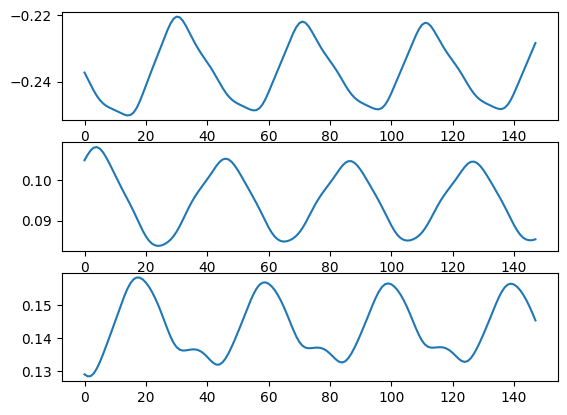

In [23]:
import pysindy as ps
from pysindy.differentiation import FiniteDifference
gru_outs, sindy_outs = shred.gru_outputs(test_dataset.X[:150,:], sindy=True)
differentiation_method = FiniteDifference()

fig, ax = plt.subplots(latent_dim)
for i in range(latent_dim):
    ax[i].plot(gru_outs[1:,0,i].detach().cpu().numpy())

### Model discovery with SINDy

The following code block extracts latent states using a GRU model. Each of the first three dimensions is normalized and re-scaled to [-1,1]. A SINDy model is then set up with a polynomial library. This SINDy model is fitted to the data and later used to simulate the dynamics for comparison with the original GRU latent trajectories.

The hyperparameters for the SINDy model are set as follows:
- **Differentiation Method:** Finite difference is used to compute numerical derivatives. When the latent states trajectories are noisy, one should consider to use ps.differentiation.SmoothedFiniteDifference().
- **Optimizer Sequantially thresholded least-squares: STLSQ:**  
  - *Threshold:* 0.8, which controls the sparsity level by eliminating coefficients below this value.
  - *Alpha:* 0.05, L2 regularization.
- **Optimizer Mixed-interger optimization: MIOSR:**  
  - *group_sparsity:* how many termseach equations should include.
- **Feature Library:** Here we only include polynomial features up to degree 1, ensuring only linear terms are considered in the model. Practically this could set up to degree 3 which will include more nonlinear terms.

For model selection, a simple baseline standard is to visually examine how the long-term extrapolation behaves. We can pick the model that fits the data well. It is also possible to include metrics (like the MSE) to quantitatively measure these quantities.

(x0)' = -0.292 1 + -1.973 x0 + -2.310 x1 + -1.249 x2
(x1)' = 0.196 1 + 0.906 x0 + 0.385 x1 + -0.063 x2
(x2)' = 0.136 1 + 1.390 x0 + 2.380 x1 + 1.589 x2


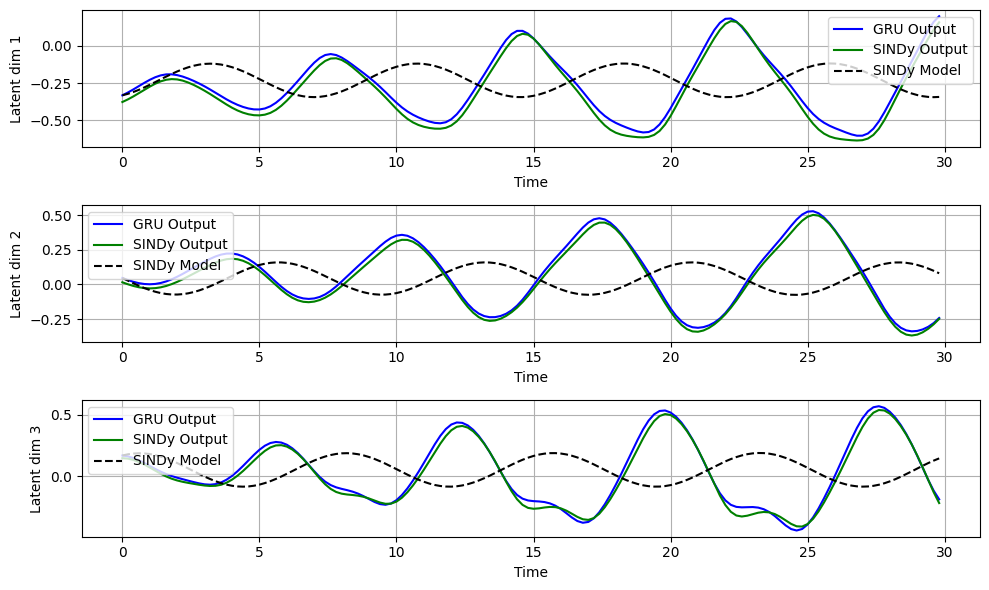

In [24]:
# Parameters
time_steps = 150
latent_dim = 3
poly_order = 1
threshold = 0.005
alpha = 0.05
dt = 0.2

# Get GRU outputs for the entire dataset
gru_outs_full, sindy_outs = shred.gru_outputs(train_dataset.X, sindy=True)
gru_outs_full = gru_outs_full[:, 0, :]  # Shape: (total_time_steps, latent_dim)
sindy_outs = sindy_outs[:, 0, :]


################ Normalization ##############
# gru_out
gru_outs_full[:,0] = (gru_outs_full[:,0] - torch.min(gru_outs_full[:,0])) / (torch.max(gru_outs_full[:,0])-torch.min(gru_outs_full[:,0]))
gru_outs_full[:,1] = (gru_outs_full[:,1] - torch.min(gru_outs_full[:,1])) / (torch.max(gru_outs_full[:,1])-torch.min(gru_outs_full[:,1]))
gru_outs_full[:,2] = (gru_outs_full[:,2] - torch.min(gru_outs_full[:,2])) / (torch.max(gru_outs_full[:,2])-torch.min(gru_outs_full[:,2]))

gru_outs_full = 2 * gru_outs_full - 1

# sindy_out
sindy_outs[:,0] = (sindy_outs[:,0] - torch.min(sindy_outs[:,0])) / (torch.max(sindy_outs[:,0])-torch.min(sindy_outs[:,0]))
sindy_outs[:,1] = (sindy_outs[:,1] - torch.min(sindy_outs[:,1])) / (torch.max(sindy_outs[:,1])-torch.min(sindy_outs[:,1]))
sindy_outs[:,2] = (sindy_outs[:,2] - torch.min(sindy_outs[:,2])) / (torch.max(sindy_outs[:,2])-torch.min(sindy_outs[:,2]))

sindy_outs = 2 * sindy_outs - 1
#############################################


# Calculate number of trajectories
total_time_steps = gru_outs_full.shape[0]
num_trajectories = total_time_steps // time_steps

# Collect multiple trajectories
all_gru_outs = []
all_sindy_outs = []
for traj_idx in range(num_trajectories):
    start_idx = traj_idx * time_steps
    end_idx = (traj_idx + 1) * time_steps
    gru_outs = gru_outs_full[start_idx:end_idx, :]
    sindy_traj_outs = sindy_outs[start_idx:end_idx, :]

    all_gru_outs.append(gru_outs.detach().cpu().numpy())  # Convert to numpy
    all_sindy_outs.append(sindy_traj_outs.detach().cpu().numpy())


# SINDy model setup
differentiation_method = ps.differentiation.FiniteDifference()
model = ps.SINDy(
    optimizer=ps.STLSQ(threshold=threshold, alpha=0.05),
    differentiation_method=differentiation_method,
    feature_library=ps.PolynomialLibrary(degree=poly_order)
)

# Fit SINDy model
model.fit(x=all_gru_outs, t=dt, ensemble=False, multiple_trajectories=True)
model.print()

# Simulate one trajectory
t_train = np.arange(0, time_steps * dt, dt)
init_cond = all_gru_outs[0][0, :]
x_sim = model.simulate(init_cond, t_train)

# Plot results
fig, ax = plt.subplots(latent_dim, 1, figsize=(10, 2 * latent_dim))
for i in range(latent_dim):
    ax[i].plot(t_train, all_gru_outs[0][:, i], label="GRU Output", color="blue")
    ax[i].plot(t_train, all_sindy_outs[0][:, i], label="SINDy Output", color="green")
    ax[i].plot(t_train, x_sim[:, i], "--", label="SINDy Model", color="black")
    ax[i].set_xlabel("Time")
    ax[i].set_ylabel(f"Latent dim {i+1}")
    ax[i].legend()
    ax[i].grid(True)
plt.tight_layout()
plt.show()


##### Running some samples

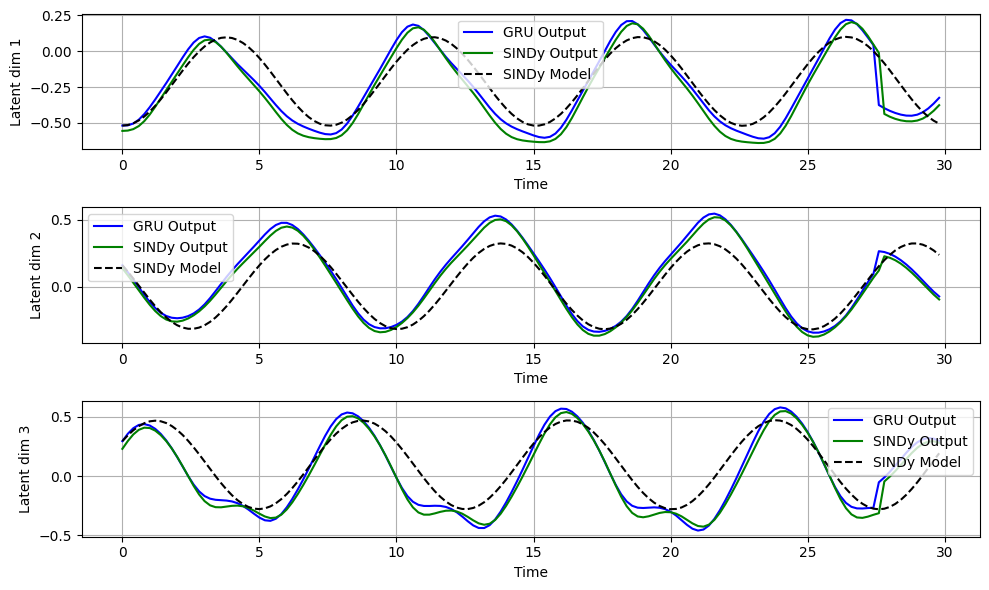

In [25]:
# Simulate one trajectory
num = 22
t_train = np.arange(0, time_steps * dt, dt)
init_cond = all_gru_outs[num][0, :]
x_sim = model.simulate(init_cond, t_train)

# Plot results
fig, ax = plt.subplots(latent_dim, 1, figsize=(10, 2 * latent_dim))
for i in range(latent_dim):
    ax[i].plot(t_train, all_gru_outs[num][:, i], label="GRU Output", color="blue")
    ax[i].plot(t_train, all_sindy_outs[num][:, i], label="SINDy Output", color="green")
    ax[i].plot(t_train, x_sim[:, i], "--", label="SINDy Model", color="black")
    ax[i].set_xlabel("Time")
    ax[i].set_ylabel(f"Latent dim {i+1}")
    ax[i].legend()
    ax[i].grid(True)
plt.tight_layout()
plt.show()

## Testing the model

In [26]:
import torch
import matplotlib.pyplot as plt

def forecast(model, x, sensor_locations, prediction_length):
    """Forecast future values by appending sensor outputs to the input sequence."""
    batch_size, seq_len, input_size = x.shape
    output_size = model.linear3.out_features if hasattr(model, 'linear3') else x.shape[-1]
    predictions = []

    current_input = x.clone()

    for _ in range(prediction_length):
        output = model.forward(current_input)
        if isinstance(output, tuple):
            output = output[0]

        sensor_output = output[:, sensor_locations]
        if sensor_output.shape[-1] != input_size:
            padded_output = torch.zeros(batch_size, input_size, device=output.device)
            padded_output[:, sensor_locations] = sensor_output
        else:
            padded_output = sensor_output

        padded_output = padded_output.unsqueeze(1)
        current_input = torch.cat([current_input[:, 1:, :], padded_output], dim=1)
        predictions.append(output.unsqueeze(1))

    return torch.cat(predictions, dim=1)


torch.Size([201, 6])


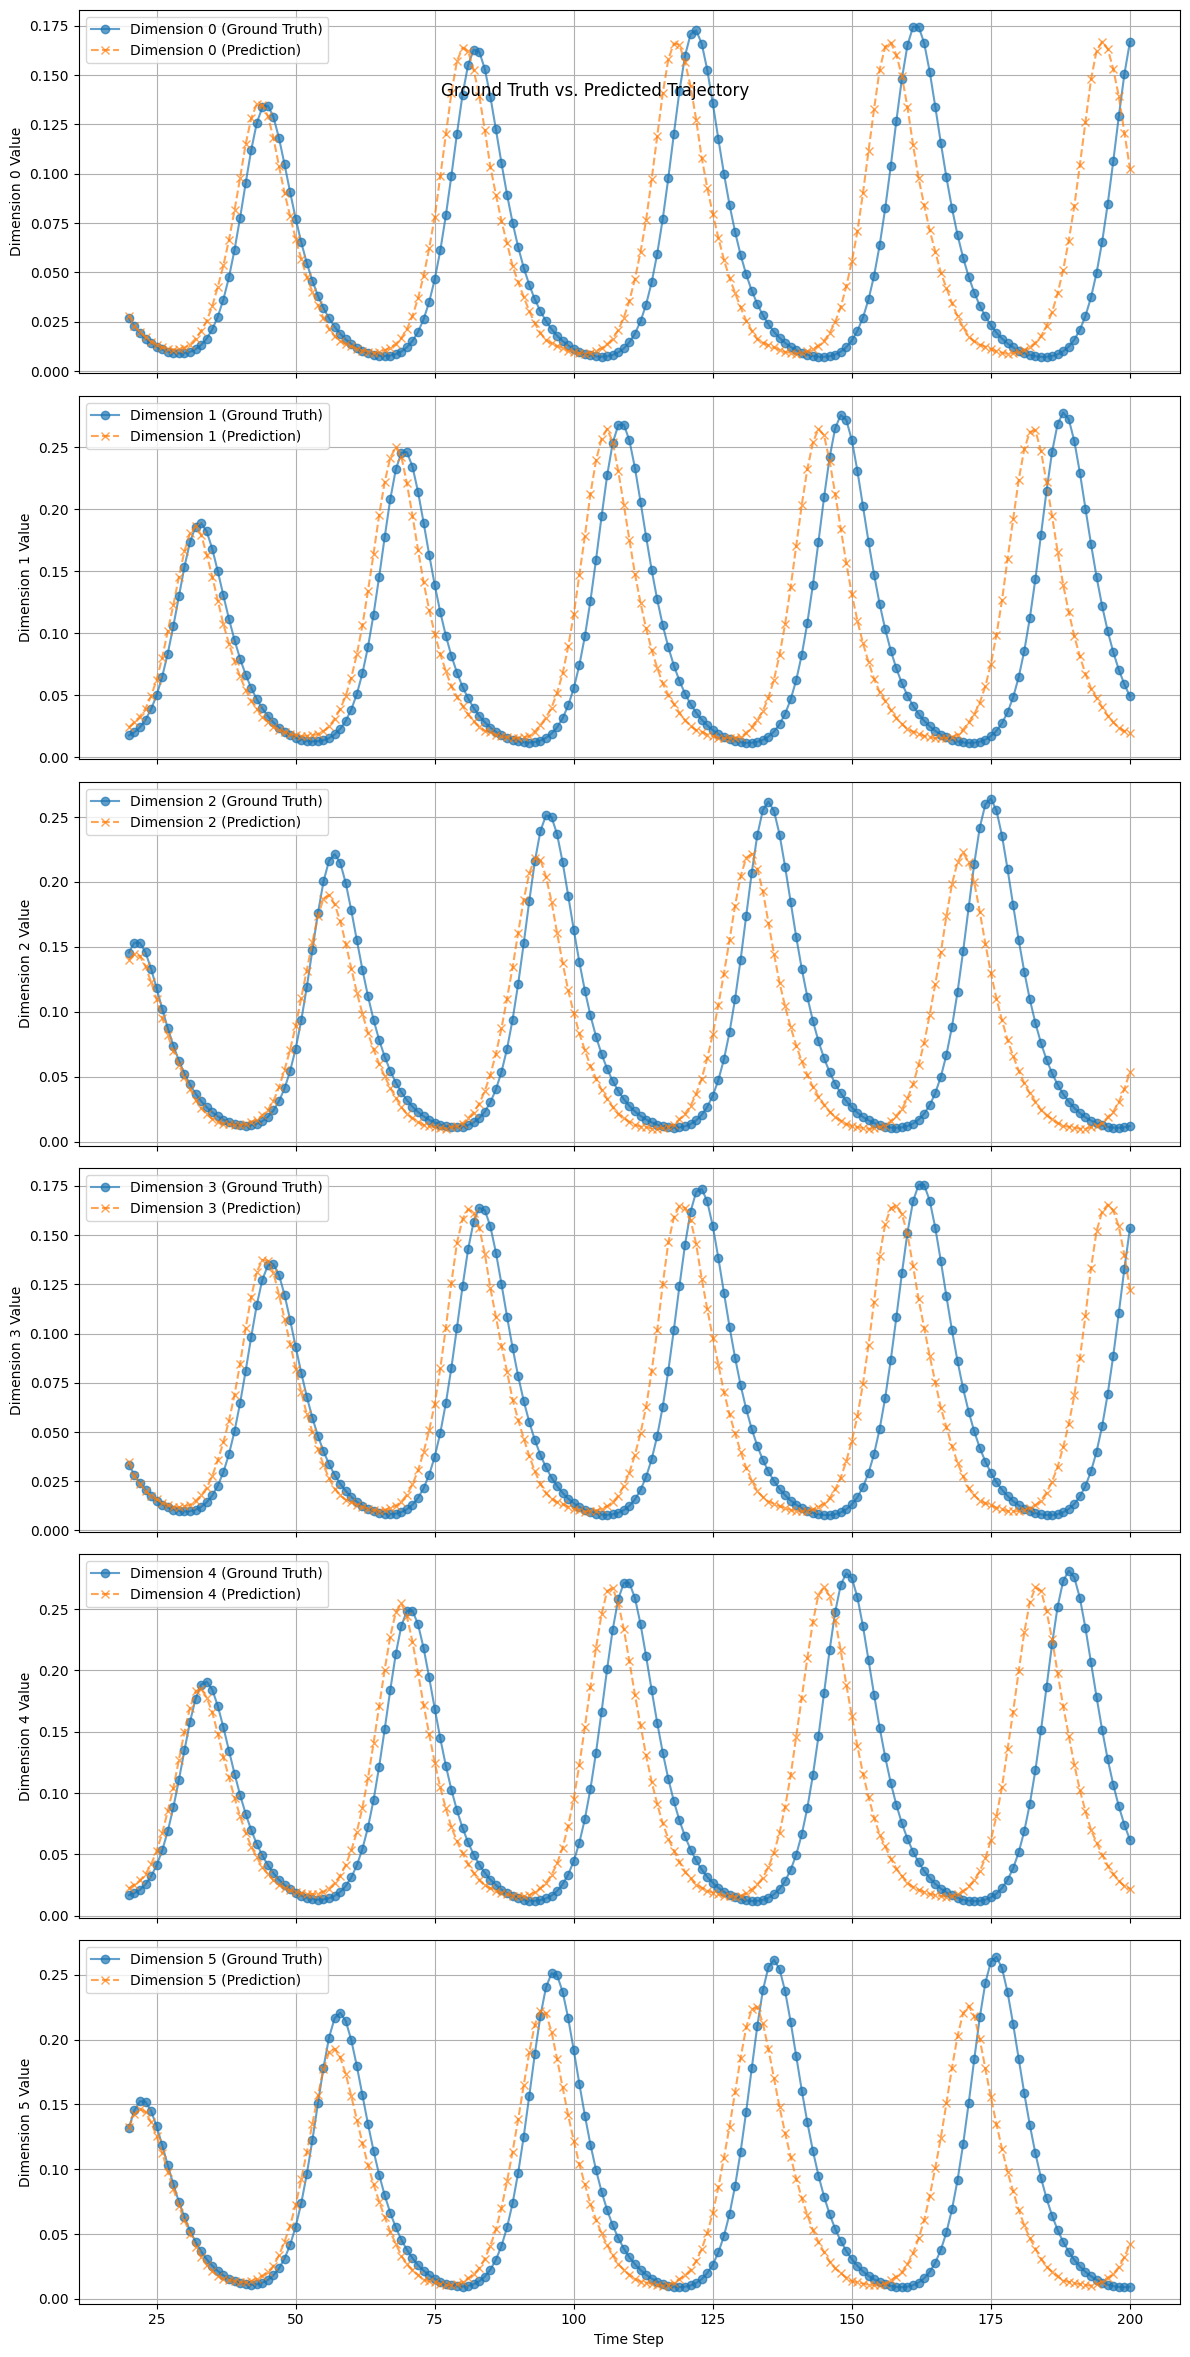

In [31]:
# Setup
given_time_steps = 20  # Initial sequence length
sensor_locations = [0, 1, 2]  # Sensor indices for input selection
traj = torch.tensor(testing_traj[13], dtype=torch.float32).to(device)
print(traj.shape)  # Shape after selecting sensor dimensions
prediction_lenght = len(traj) - given_time_steps
prediction = forecast(shred, traj[:given_time_steps, sensor_locations].unsqueeze(0), sensor_locations, prediction_length=prediction_lenght)
prediction = prediction.detach().cpu().numpy()

# Plotting
fig, axes = plt.subplots(traj.shape[1], 1, figsize=(12, 4 * traj.shape[1]), sharex=True)
ground_truth_time = range(given_time_steps, traj.shape[0])  # Time steps for ground truth
prediction_time = range(given_time_steps, given_time_steps + prediction.shape[1])  # Time steps for prediction

for i in range(traj.shape[1]):
    ax = axes[i] if traj.shape[1] > 1 else axes
    ax.plot(ground_truth_time, traj[given_time_steps:, i].cpu().numpy(), label=f'Dimension {i} (Ground Truth)',
            linestyle='-', marker='o', alpha=0.7)
    ax.plot(prediction_time, prediction[0, :, i], label=f'Dimension {i} (Prediction)',
            linestyle='--', marker='x', alpha=0.7)
    ax.set_ylabel(f'Dimension {i} Value')
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel('Time Step')
fig.suptitle('Ground Truth vs. Predicted Trajectory', y=0.95)
plt.tight_layout()
plt.show()

## Testing on Longer Trajectory

In [32]:
from scipy.integrate import odeint

class RepressilatorModel():
    """
    .. math::
        \\dot{m_0} = -m_0 + \\frac{\\alpha}{1 + p_2^n} + \\alpha_0

        \\dot{m_1} = -m_1 + \\frac{\\alpha}{1 + p_0^n} + \\alpha_0

        \\dot{m_2} = -m_2 + \\frac{\\alpha}{1 + p_1^n} + \\alpha_0

        \\dot{p_0} = -\\beta (p_0 - m_0)

        \\dot{p_1} = -\\beta (p_1 - m_1)

        \\dot{p_2} = -\\beta (p_2 - m_2)

    With parameters ``alpha_0``, ``alpha``, ``beta``, and ``n``.

    Parameters
    ----------
    y0
        The system's initial state, must have 6 entries all >=0.
    """

    def __init__(self, y0=None):
        super(RepressilatorModel, self).__init__()

        if y0 is None:
            self._y0 = np.array([0, 0, 0, 2, 1, 3])
        else:
            self._y0 = np.array(y0, dtype=float)
            if len(self._y0) != 6:
                raise ValueError('Initial value must have size 6.')
            if np.any(self._y0 < 0):
                raise ValueError('Initial states can not be negative.')

    def n_outputs(self):
        return 6

    def n_parameters(self):
        return 4

    def _rhs(self, y, t, alpha_0, alpha, beta, n):
        """
        Calculates the model RHS.
        """
        dy = np.zeros(6)
        dy[0] = -y[0] + alpha / (1 + y[5]**n) + alpha_0
        dy[1] = -y[1] + alpha / (1 + y[3]**n) + alpha_0
        dy[2] = -y[2] + alpha / (1 + y[4]**n) + alpha_0
        dy[3] = -beta * (y[3] - y[0])
        dy[4] = -beta * (y[4] - y[1])
        dy[5] = -beta * (y[5] - y[2])
        return dy

    def simulate(self, parameters, times):
        alpha_0, alpha, beta, n = parameters
        y = odeint(self._rhs, self._y0, times, (alpha_0, alpha, beta, n))
        return y[:, :]

    def suggested_parameters(self):
        return np.array([1, 1000, 5, 2])

    def suggested_times(self):
        return np.linspace(0, 40, 400)

In [41]:
#y = [15, 20, 80,  90, 30, 70]
y = np.random.rand(6) * 100
#y = y = [70, 10, 3,  65, 12, 3]
print('Initial conditions:', y)
Repressilator_model = RepressilatorModel(y0=y)

parameters = Repressilator_model.suggested_parameters()
times =  np.linspace(0,100, 501)
traj = Repressilator_model.simulate(parameters, times)


# Normalize the trajectory
traj = sc.fit_transform(traj)
traj = torch.tensor(traj, dtype=torch.float32).to(device)
print(traj[0])

Initial conditions: [26.45556121 77.42336894 45.61503322 56.84339489  1.87898004 61.76354971]
tensor([0.3486, 1.0000, 0.6338, 0.8197, 0.0000, 0.8961], device='cuda:0')


torch.Size([501, 6])


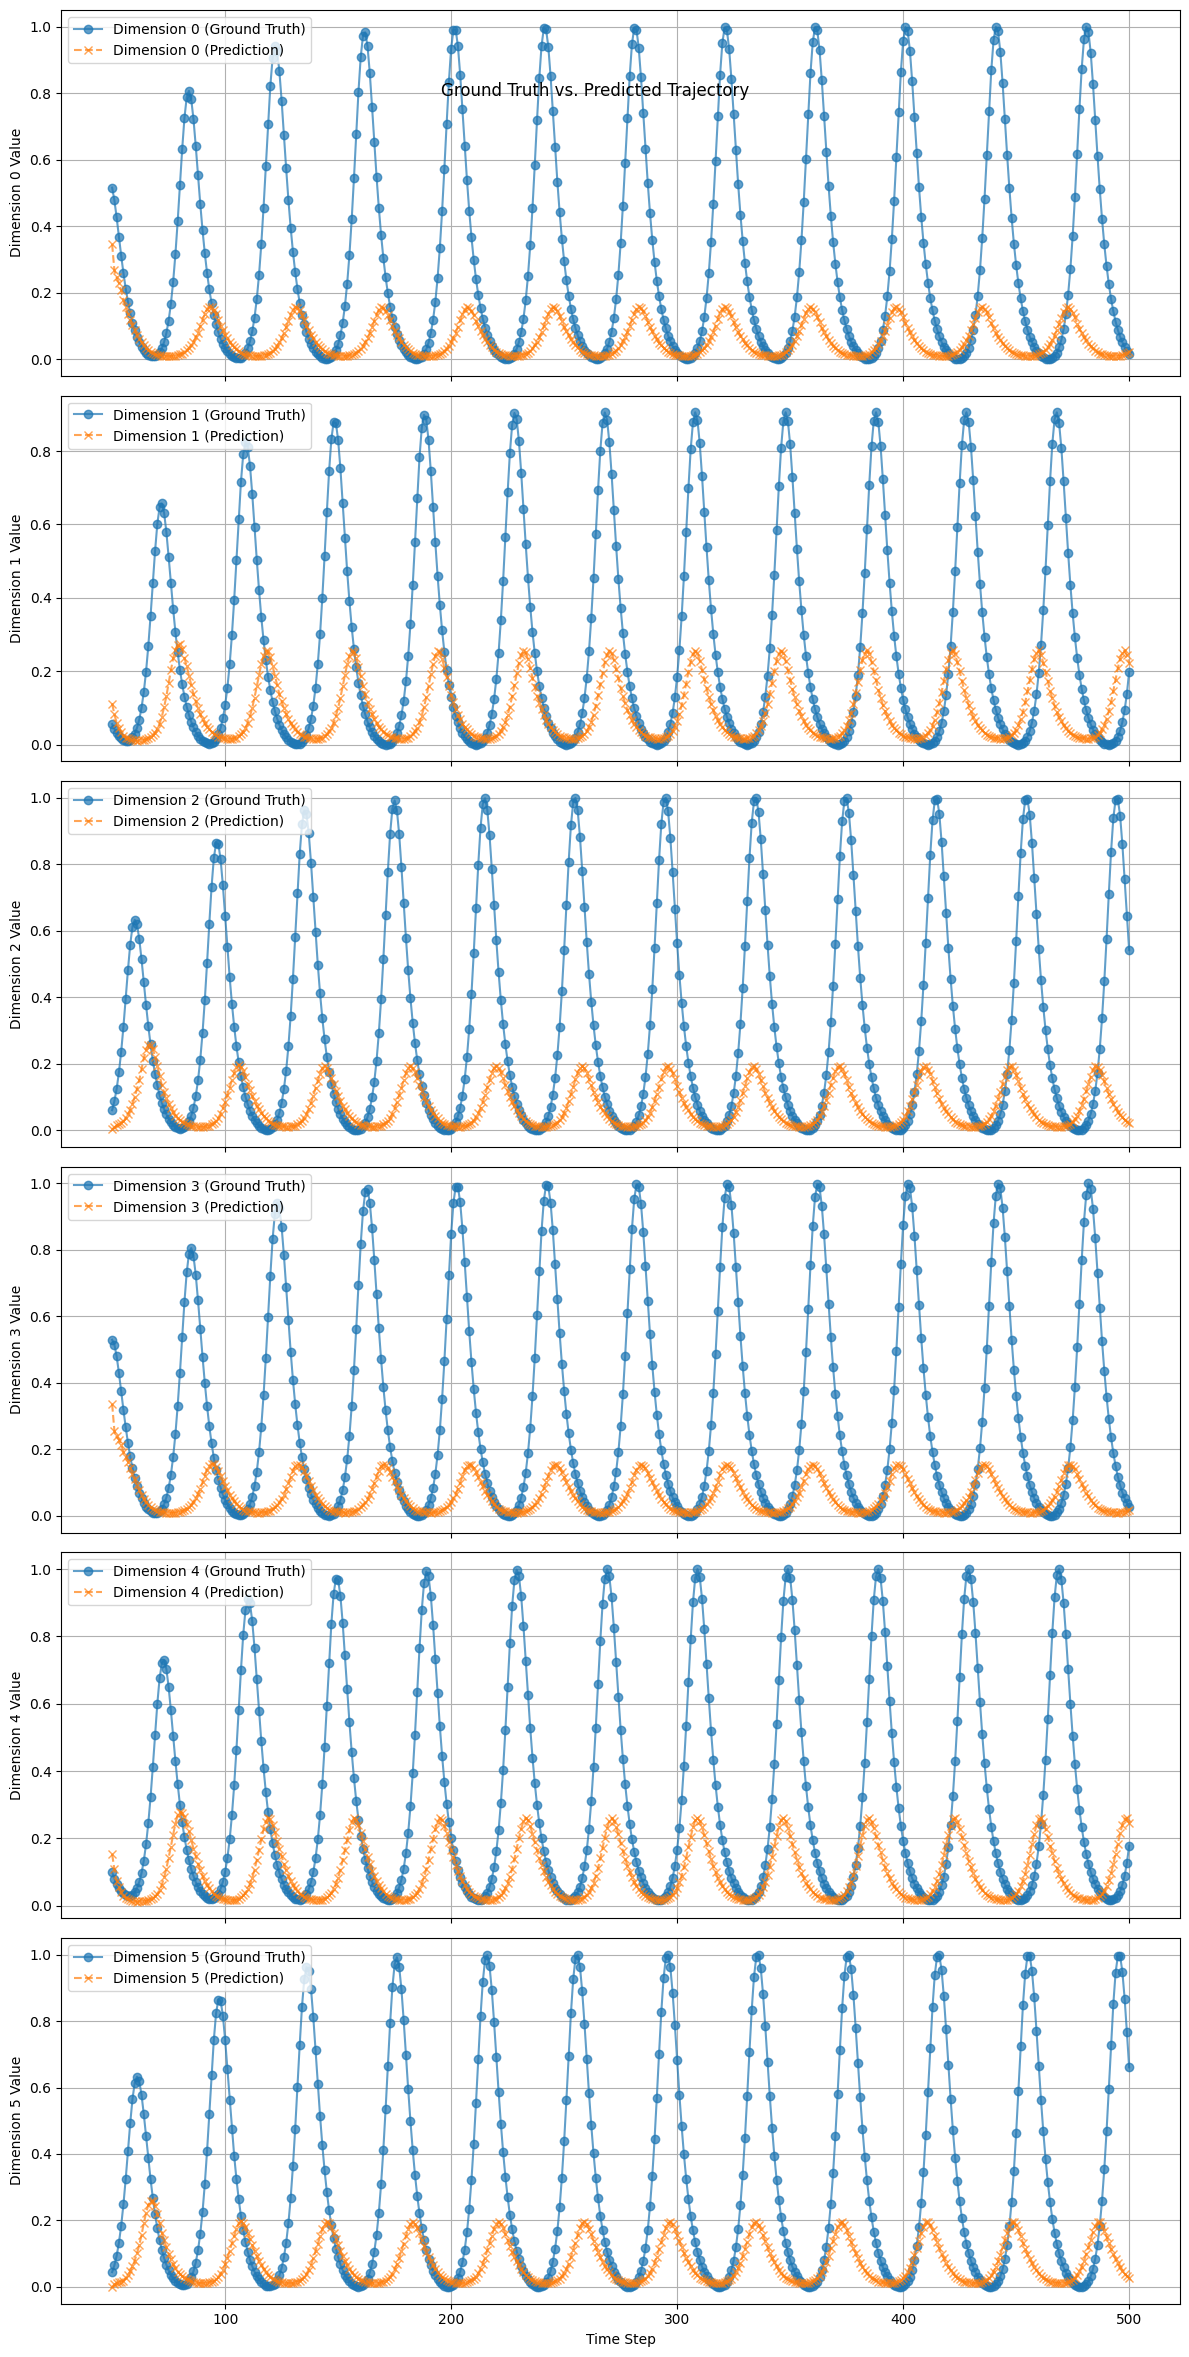

In [43]:
# Setup
given_time_steps = 50  # Initial sequence length
sensor_locations = [0, 1, 2]  # Sensor indices for input selection
print(traj.shape)  # Shape after selecting sensor dimensions
prediction_lenght = len(traj) - given_time_steps
prediction = forecast(shred, traj[:given_time_steps, sensor_locations].unsqueeze(0), sensor_locations, prediction_length=prediction_lenght)
prediction = prediction.detach().cpu().numpy()

# Plotting
fig, axes = plt.subplots(traj.shape[1], 1, figsize=(12, 4 * traj.shape[1]), sharex=True)
ground_truth_time = range(given_time_steps, traj.shape[0])  # Time steps for ground truth
prediction_time = range(given_time_steps, given_time_steps + prediction.shape[1])  # Time steps for prediction

for i in range(traj.shape[1]):
    ax = axes[i] if traj.shape[1] > 1 else axes
    ax.plot(ground_truth_time, traj[given_time_steps:, i].cpu().numpy(), label=f'Dimension {i} (Ground Truth)',
            linestyle='-', marker='o', alpha=0.7)
    ax.plot(prediction_time, prediction[0, :, i], label=f'Dimension {i} (Prediction)',
            linestyle='--', marker='x', alpha=0.7)
    ax.set_ylabel(f'Dimension {i} Value')
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel('Time Step')
fig.suptitle('Ground Truth vs. Predicted Trajectory', y=0.95)
plt.tight_layout()
plt.show()